In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [3]:

df = pd.read_csv("C:/Users/hp/OneDrive/Documents/Downloads/super_store_sales.csv", 
                 encoding='latin1')  

In [4]:
print(df)

            Order ID                    Order Date  \
0     CA-2020-125367       Thursday, July 23, 2020   
1     CA-2020-117240       Thursday, July 23, 2020   
2     CA-2020-107132         Friday, June 26, 2020   
3     CA-2020-157987  Wednesday, September 2, 2020   
4     CA-2020-123043       Monday, August 24, 2020   
...              ...                           ...   
5896  CA-2019-119935     Sunday, November 10, 2019   
5897  CA-2019-145177     Sunday, November 10, 2019   
5898  CA-2019-116722     Monday, November 11, 2019   
5899  CA-2019-147585    Thursday, November 7, 2019   
5900  CA-2019-116337    Thursday, November 7, 2019   

                        Ship Date       Ship Mode Customer ID  \
0         Thursday, July 30, 2020  Standard Class    NM-18445   
1          Tuesday, July 28, 2020  Standard Class    CP-12340   
2          Tuesday, June 30, 2020  Standard Class    SC-20260   
3       Sunday, September 6, 2020  Standard Class    AC-10615   
4       Saturday, August 2

In [5]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,AvgDelivery
0,CA-2020-125367,"Thursday, July 23, 2020","Thursday, July 30, 2020",Standard Class,NM-18445,Nathan Mautz,Home Office,United States,New York City,New York,...,OFF-BI-10002412,Office Supplies,Binders,Wilson Jones Snap Scratch Pad Binder Tool fo...,120.920,3,4.3500,0,COD,7
1,CA-2020-117240,"Thursday, July 23, 2020","Tuesday, July 28, 2020",Standard Class,CP-12340,Christine Phan,Corporate,United States,New York City,New York,...,OFF-BI-10000848,Office Supplies,Binders,Angle-D Ring Binders,116.128,3,4.2666,0,Cards,5
2,CA-2020-107132,"Friday, June 26, 2020","Tuesday, June 30, 2020",Standard Class,SC-20260,Scott Cohen,Corporate,United States,New York City,New York,...,OFF-BI-10001071,Office Supplies,Binders,GBC ProClick Punch Binding System,127.368,2,37.1084,0,Cards,4
3,CA-2020-157987,"Wednesday, September 2, 2020","Sunday, September 6, 2020",Standard Class,AC-10615,Ann Chong,Corporate,United States,New York City,New York,...,OFF-BI-10004970,Office Supplies,Binders,"ACCOHIDE 3-Ring Binder, Blue, 1""",104.432,8,8.9208,0,COD,4
4,CA-2020-123043,"Monday, August 24, 2020","Saturday, August 29, 2020",Standard Class,AH-10195,Alan Haines,Corporate,United States,New York City,New York,...,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,121.672,4,7.7100,0,Cards,5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5901 non-null   object 
 1   Order Date     5901 non-null   object 
 2   Ship Date      5901 non-null   object 
 3   Ship Mode      5901 non-null   object 
 4   Customer ID    5901 non-null   object 
 5   Customer Name  5901 non-null   object 
 6   Segment        5901 non-null   object 
 7   Country        5901 non-null   object 
 8   City           5901 non-null   object 
 9   State          5901 non-null   object 
 10  Region         5901 non-null   object 
 11  Product ID     5901 non-null   object 
 12  Category       5901 non-null   object 
 13  Sub-Category   5901 non-null   object 
 14  Product Name   5901 non-null   object 
 15  Sales          5901 non-null   float64
 16  Quantity       5901 non-null   int64  
 17  Profit         5901 non-null   float64
 18  Returns 

In [7]:
df.describe()

,Sales,Quantity,Profit,Returns,AvgDelivery
count,5901.000000,5901.000000,5901.000000,5901.000000,5901.000000
mean,265.345589,3.781901,29.700408,0.048636,3.926962
std,474.260645,2.212917,259.589138,0.215124,1.792050
min,0.836000,1.000000,-6599.978000,0.000000,0.000000
25%,71.976000,2.000000,1.795500,0.000000,3.000000
50%,128.648000,3.000000,8.502500,0.000000,4.000000
75%,265.170000,5.000000,28.615000,0.000000,5.000000
max,9099.930000,14.000000,8399.976000,1.000000,8.000000


In [8]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,AvgDelivery
0,CA-2020-125367,"Thursday, July 23, 2020","Thursday, July 30, 2020",Standard Class,NM-18445,Nathan Mautz,Home Office,United States,New York City,New York,...,OFF-BI-10002412,Office Supplies,Binders,Wilson Jones Snap Scratch Pad Binder Tool fo...,120.920,3,4.3500,0,COD,7
1,CA-2020-117240,"Thursday, July 23, 2020","Tuesday, July 28, 2020",Standard Class,CP-12340,Christine Phan,Corporate,United States,New York City,New York,...,OFF-BI-10000848,Office Supplies,Binders,Angle-D Ring Binders,116.128,3,4.2666,0,Cards,5
2,CA-2020-107132,"Friday, June 26, 2020","Tuesday, June 30, 2020",Standard Class,SC-20260,Scott Cohen,Corporate,United States,New York City,New York,...,OFF-BI-10001071,Office Supplies,Binders,GBC ProClick Punch Binding System,127.368,2,37.1084,0,Cards,4
3,CA-2020-157987,"Wednesday, September 2, 2020","Sunday, September 6, 2020",Standard Class,AC-10615,Ann Chong,Corporate,United States,New York City,New York,...,OFF-BI-10004970,Office Supplies,Binders,"ACCOHIDE 3-Ring Binder, Blue, 1""",104.432,8,8.9208,0,COD,4
4,CA-2020-123043,"Monday, August 24, 2020","Saturday, August 29, 2020",Standard Class,AH-10195,Alan Haines,Corporate,United States,New York City,New York,...,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,121.672,4,7.7100,0,Cards,5


In [9]:
df.tail()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,AvgDelivery
5896,CA-2019-119935,"Sunday, November 10, 2019","Thursday, November 14, 2019",Standard Class,KM-16225,Kalyca Meade,Corporate,United States,Springfield,Missouri,...,FUR-FU-10001085,Furniture,Furnishings,3M Polarizing Light Filter Sleeves,37.300,2,17.1580,0,Cards,4
5897,CA-2019-145177,"Sunday, November 10, 2019","Thursday, November 14, 2019",Standard Class,PP-18955,Paul Prost,Home Office,United States,Springfield,Ohio,...,FUR-FU-10000758,Furniture,Furnishings,DAX Natural Wood-Tone Poster Frame,148.288,7,29.6576,0,Cards,4
5898,CA-2019-116722,"Monday, November 11, 2019","Saturday, November 16, 2019",Standard Class,LP-17080,Liz Pelletier,Consumer,United States,San Francisco,California,...,FUR-FU-10001934,Furniture,Furnishings,Magnifier Swing Arm Lamp,41.960,2,10.9096,0,Cards,5
5899,CA-2019-147585,"Thursday, November 7, 2019","Tuesday, November 12, 2019",Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,San Francisco,California,...,FUR-FU-10002597,Furniture,Furnishings,"C-Line Magnetic Cubicle Keepers, Clear Polypro...",14.820,3,6.2244,0,COD,5
5900,CA-2019-116337,"Thursday, November 7, 2019","Tuesday, November 12, 2019",Standard Class,MC-17845,Michael Chen,Consumer,United States,Dallas,Texas,...,FUR-FU-10002030,Furniture,Furnishings,"Executive Impressions 14"" Contract Wall Clock ...",44.460,5,-17.7840,0,Cards,5


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5901 non-null   object 
 1   Order Date     5901 non-null   object 
 2   Ship Date      5901 non-null   object 
 3   Ship Mode      5901 non-null   object 
 4   Customer ID    5901 non-null   object 
 5   Customer Name  5901 non-null   object 
 6   Segment        5901 non-null   object 
 7   Country        5901 non-null   object 
 8   City           5901 non-null   object 
 9   State          5901 non-null   object 
 10  Region         5901 non-null   object 
 11  Product ID     5901 non-null   object 
 12  Category       5901 non-null   object 
 13  Sub-Category   5901 non-null   object 
 14  Product Name   5901 non-null   object 
 15  Sales          5901 non-null   float64
 16  Quantity       5901 non-null   int64  
 17  Profit         5901 non-null   float64
 18  Returns 

In [13]:
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Profit           0
Returns          0
Payment Mode     0
AvgDelivery      0
dtype: int64

In [27]:
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())
df['Profit'] = df['Profit'].fillna(0)
df

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,AvgDelivery,Package_LPA,Degree_Marks,Marks_Category
0,CA-2020-125367,"Thursday, July 23, 2020","Thursday, July 30, 2020",Standard Class,NM-18445,Nathan Mautz,Home Office,United States,New York City,New York,...,Wilson Jones Snap Scratch Pad Binder Tool fo...,120.920,3,4.3500,0,COD,7,0,0,Not Eligible
1,CA-2020-117240,"Thursday, July 23, 2020","Tuesday, July 28, 2020",Standard Class,CP-12340,Christine Phan,Corporate,United States,New York City,New York,...,Angle-D Ring Binders,116.128,3,4.2666,0,Cards,5,0,0,Not Eligible
2,CA-2020-107132,"Friday, June 26, 2020","Tuesday, June 30, 2020",Standard Class,SC-20260,Scott Cohen,Corporate,United States,New York City,New York,...,GBC ProClick Punch Binding System,127.368,2,37.1084,0,Cards,4,0,0,Not Eligible
3,CA-2020-157987,"Wednesday, September 2, 2020","Sunday, September 6, 2020",Standard Class,AC-10615,Ann Chong,Corporate,United States,New York City,New York,...,"ACCOHIDE 3-Ring Binder, Blue, 1""",104.432,8,8.9208,0,COD,4,0,0,Not Eligible
4,CA-2020-123043,"Monday, August 24, 2020","Saturday, August 29, 2020",Standard Class,AH-10195,Alan Haines,Corporate,United States,New York City,New York,...,DXL Angle-View Binders with Locking Rings by S...,121.672,4,7.7100,0,Cards,5,0,0,Not Eligible
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5896,CA-2019-119935,"Sunday, November 10, 2019","Thursday, November 14, 2019",Standard Class,KM-16225,Kalyca Meade,Corporate,United States,Springfield,Missouri,...,3M Polarizing Light Filter Sleeves,37.300,2,17.1580,0,Cards,4,0,0,Not Eligible
5897,CA-2019-145177,"Sunday, November 10, 2019","Thursday, November 14, 2019",Standard Class,PP-18955,Paul Prost,Home Office,United States,Springfield,Ohio,...,DAX Natural Wood-Tone Poster Frame,148.288,7,29.6576,0,Cards,4,0,0,Not Eligible
5898,CA-2019-116722,"Monday, November 11, 2019","Saturday, November 16, 2019",Standard Class,LP-17080,Liz Pelletier,Consumer,United States,San Francisco,California,...,Magnifier Swing Arm Lamp,41.960,2,10.9096,0,Cards,5,0,0,Not Eligible
5899,CA-2019-147585,"Thursday, November 7, 2019","Tuesday, November 12, 2019",Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,San Francisco,California,...,"C-Line Magnetic Cubicle Keepers, Clear Polypro...",14.820,3,6.2244,0,COD,5,0,0,Not Eligible


In [28]:
df['Profit_Status'] = np.where(df['Profit'] > 0, 'Profit', 'Loss')


# Data Visualization

1) Total Sales by Category

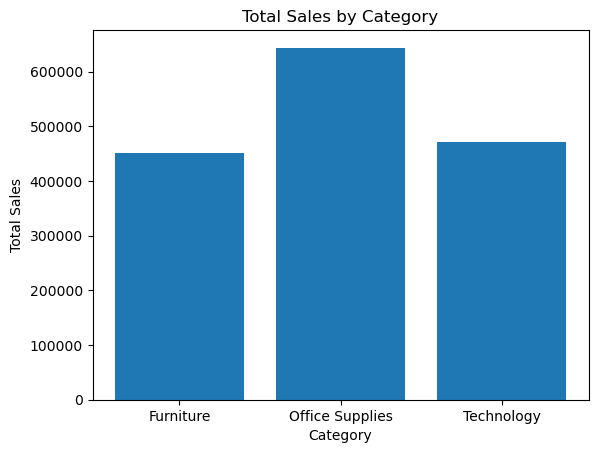

In [29]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure()
plt.bar(category_sales.index, category_sales.values)
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Total Sales by Category")
plt.show()


2) Sales by Sub-Category

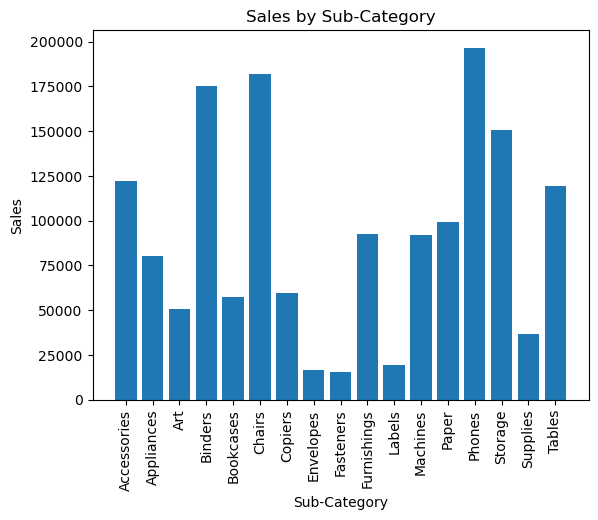

In [30]:
sub_sales = df.groupby('Sub-Category')['Sales'].sum()

plt.figure()
plt.bar(sub_sales.index, sub_sales.values)
plt.xticks(rotation=90)
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.title("Sales by Sub-Category")
plt.show()


3) Profit vs loss count

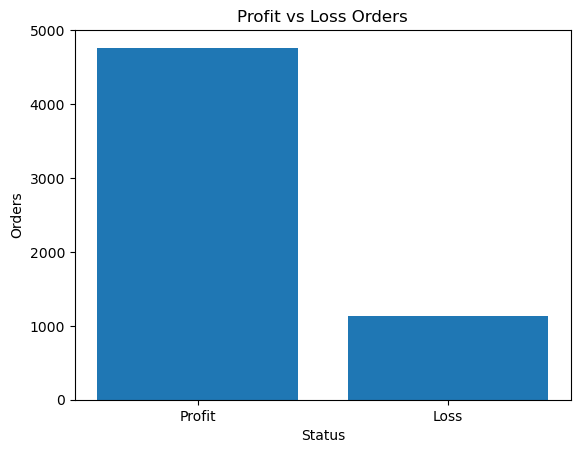

In [31]:
profit_count = df['Profit_Status'].value_counts()

plt.figure()
plt.bar(profit_count.index, profit_count.values)
plt.xlabel("Status")
plt.ylabel("Orders")
plt.title("Profit vs Loss Orders")
plt.show()


4) Region wise Sales

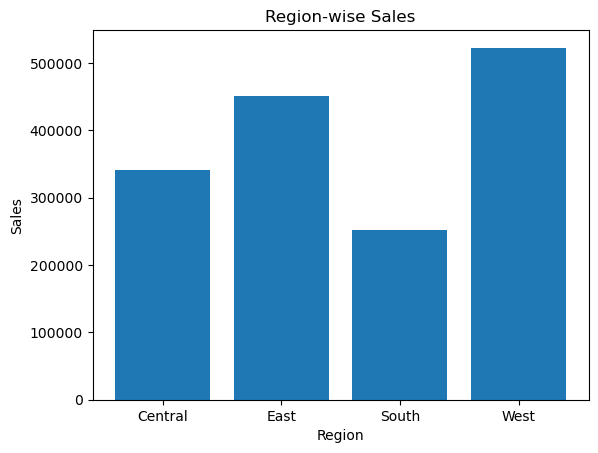

In [32]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure()
plt.bar(region_sales.index, region_sales.values)
plt.xlabel("Region")
plt.ylabel("Sales")
plt.title("Region-wise Sales")
plt.show()


5) Sales Distribution

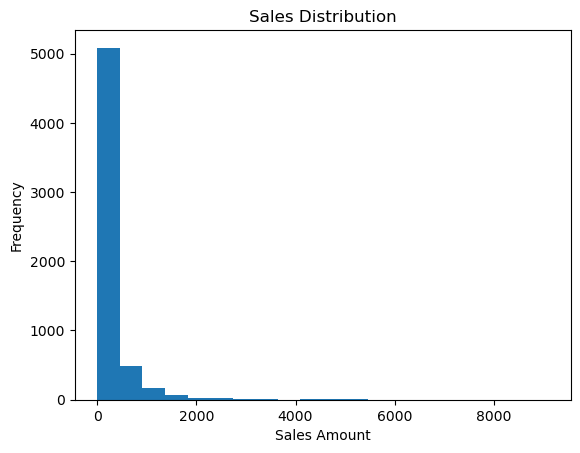

In [33]:
plt.figure()
plt.hist(df['Sales'], bins=20)
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.title("Sales Distribution")
plt.show()


6) Quantity vs Sales 

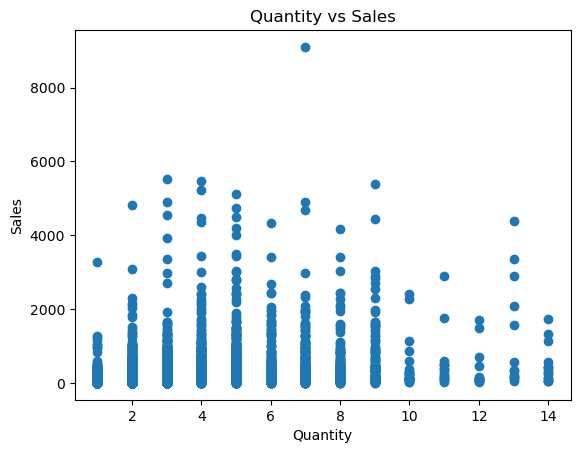

In [34]:
plt.figure()
plt.scatter(df['Quantity'], df['Sales'])
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Quantity vs Sales")
plt.show()

# Machine Learning

In [40]:
X = df[['Quantity']]
y = df['Sales']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [42]:
# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [43]:
# Prediction
y_pred = model.predict(X_test)

In [44]:
# Model Evaluation
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Mean Squared Error: 231676.27571195975
R2 Score: 0.02906199117277397


Actual vs Predicted Sales

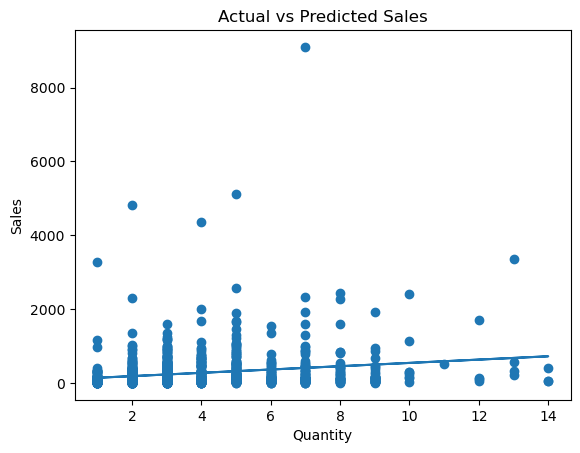

In [45]:
plt.figure()
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales")
plt.show()


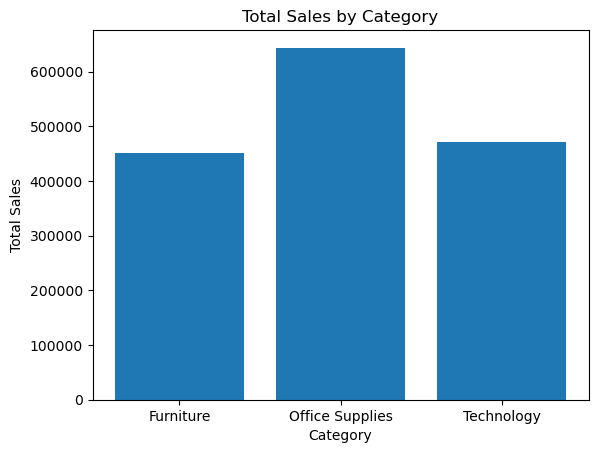

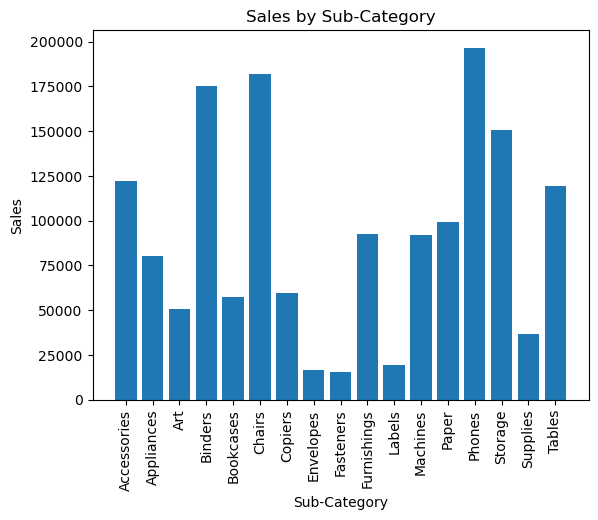

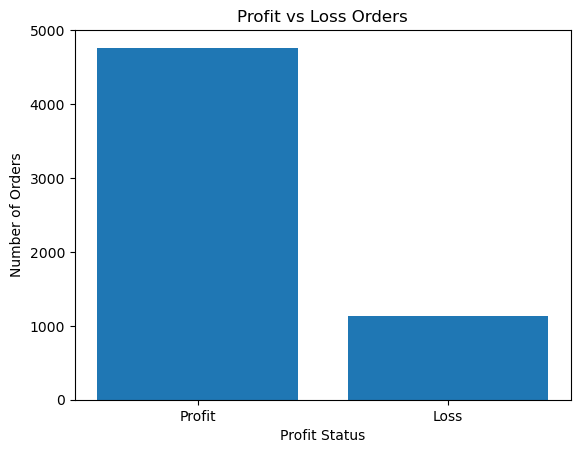

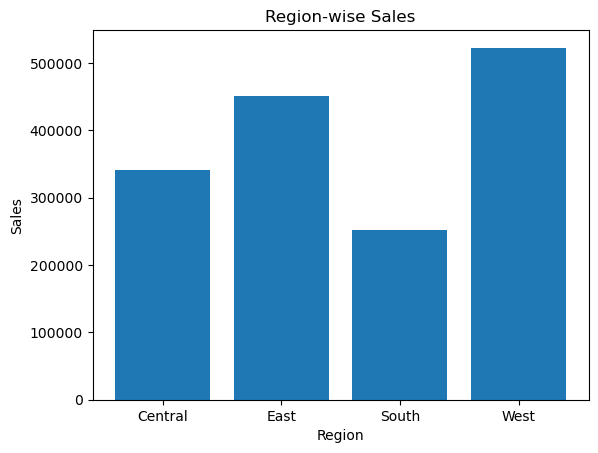

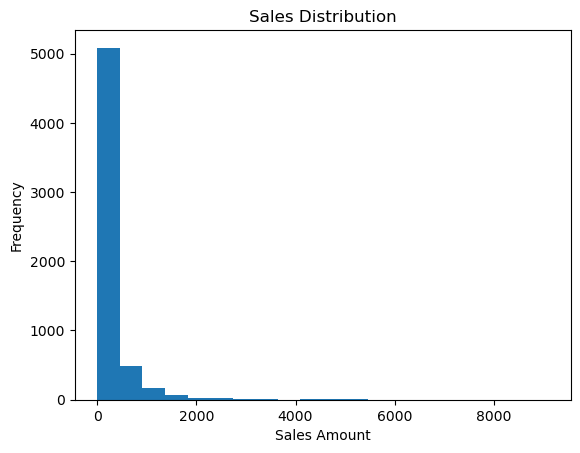

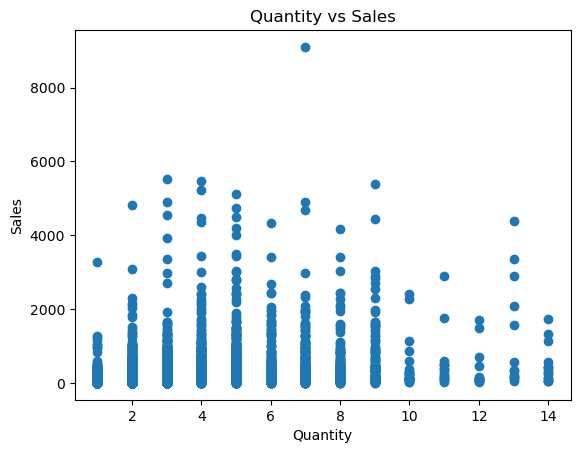

In [46]:
# -------- GRAPH 1: SALES BY CATEGORY --------
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure()
plt.bar(category_sales.index, category_sales.values)
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Total Sales by Category")
plt.show()

# -------- GRAPH 2: SALES BY SUB-CATEGORY --------
sub_category_sales = df.groupby('Sub-Category')['Sales'].sum()

plt.figure()
plt.bar(sub_category_sales.index, sub_category_sales.values)
plt.xticks(rotation=90)
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.title("Sales by Sub-Category")
plt.show()

# -------- GRAPH 3: PROFIT VS LOSS COUNT --------
profit_count = df['Profit_Status'].value_counts()

plt.figure()
plt.bar(profit_count.index, profit_count.values)
plt.xlabel("Profit Status")
plt.ylabel("Number of Orders")
plt.title("Profit vs Loss Orders")
plt.show()

# -------- GRAPH 4: REGION-WISE SALES --------
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure()
plt.bar(region_sales.index, region_sales.values)
plt.xlabel("Region")
plt.ylabel("Sales")
plt.title("Region-wise Sales")
plt.show()

# -------- GRAPH 5: SALES DISTRIBUTION --------
plt.figure()
plt.hist(df['Sales'], bins=20)
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.title("Sales Distribution")
plt.show()

# -------- GRAPH 6: QUANTITY VS SALES --------
plt.figure()
plt.scatter(df['Quantity'], df['Sales'])
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Quantity vs Sales")
plt.show()
